In [46]:
from PIL import Image
import numpy as np
import os
from collections import Counter

data_path = "../Data/Data"

image_path = os.path.join(data_path, "left0586.jpg")
label_path = os.path.join(data_path, "left0586_sup.png")

image = Image.open(image_path)
label = Image.open(label_path)

print("Original image:", image.size, image.mode)
print("Label image:", label.size, label.mode)

Original image: (1280, 720) RGB
Label image: (496, 279) RGBA


In [47]:
label_array = np.array(label)

pixels = label_array.reshape(-1, 4) if label_array.shape[-1] == 4 else label_array.reshape(-1, 3)

color_counts = Counter(map(tuple, pixels))

print("Number of unique colours:", len(color_counts))

for color, count in color_counts.most_common():
    print(color, "->", count, "pixels")

Number of unique colours: 64
(np.uint8(0), np.uint8(0), np.uint8(0), np.uint8(255)) -> 54066 pixels
(np.uint8(237), np.uint8(28), np.uint8(36), np.uint8(255)) -> 32355 pixels
(np.uint8(163), np.uint8(73), np.uint8(164), np.uint8(255)) -> 22036 pixels
(np.uint8(255), np.uint8(242), np.uint8(0), np.uint8(255)) -> 13991 pixels
(np.uint8(63), np.uint8(72), np.uint8(204), np.uint8(255)) -> 7805 pixels
(np.uint8(34), np.uint8(177), np.uint8(76), np.uint8(255)) -> 7792 pixels
(np.uint8(117), np.uint8(127), np.uint8(140), np.uint8(255)) -> 74 pixels
(np.uint8(136), np.uint8(142), np.uint8(154), np.uint8(255)) -> 40 pixels
(np.uint8(128), np.uint8(132), np.uint8(143), np.uint8(255)) -> 26 pixels
(np.uint8(20), np.uint8(23), np.uint8(37), np.uint8(255)) -> 25 pixels
(np.uint8(148), np.uint8(158), np.uint8(173), np.uint8(255)) -> 20 pixels
(np.uint8(37), np.uint8(43), np.uint8(27), np.uint8(255)) -> 18 pixels
(np.uint8(42), np.uint8(40), np.uint8(35), np.uint8(255)) -> 15 pixels
(np.uint8(40), np

In [48]:
# Main label colours

LABEL_COLORS = {
    "traversable": (237, 28, 36),
    "pavement": (255, 242, 0),
    "untraversable": (163, 73, 164),
    "green": (34, 177, 76),
    "target": (63, 72, 204),
    "sky": (0, 0, 0)
}

for name, color in LABEL_COLORS.items():
    print(name, "->", color)

traversable -> (237, 28, 36)
pavement -> (255, 242, 0)
untraversable -> (163, 73, 164)
green -> (34, 177, 76)
target -> (63, 72, 204)
sky -> (0, 0, 0)


In [49]:
label_rgb = label.convert("RGB")
label_array = np.array(label_rgb)

traversable_mask = (
    np.all(label_array == LABEL_COLORS["traversable"], axis=2) |
    np.all(label_array == LABEL_COLORS["pavement"], axis=2)
)

print("Traversable pixels:", np.sum(traversable_mask))
print("Non-traversable pixels:", np.sum(~traversable_mask))

Traversable pixels: 46346
Non-traversable pixels: 92038


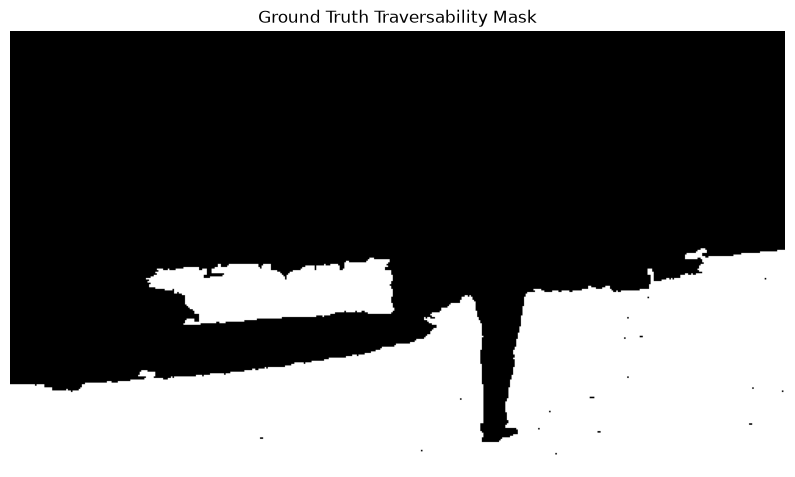

In [50]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.imshow(traversable_mask, cmap="gray")
plt.title("Ground Truth Traversability Mask")
plt.axis("off")
plt.show()

In [51]:
# Resize original image to match label dimensions

image_resized = image.resize(label.size)

print("Resized image:", image_resized.size)
print("Label image:", label.size)

Resized image: (496, 279)
Label image: (496, 279)


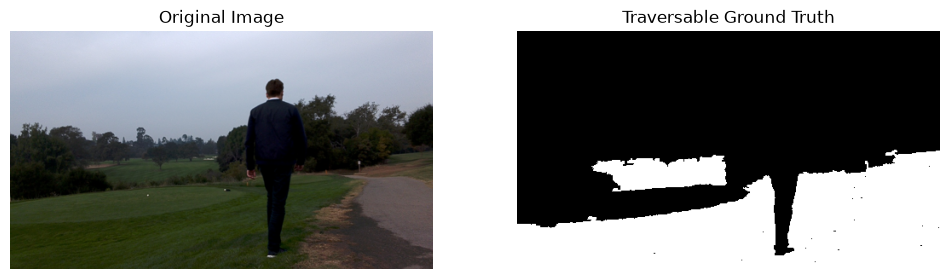

In [52]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(image_resized)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(traversable_mask, cmap="gray")
plt.title("Traversable Ground Truth")
plt.axis("off")

plt.show()

In [53]:
import glob
import os

# Find all supervised label images
label_files = sorted(glob.glob(os.path.join(data_path, "*_sup.png")))

print("Number of labelled images:", len(label_files))

for label_file in label_files:
    label_name = os.path.basename(label_file)
    original_name = label_name.replace("_sup.png", ".jpg")
    
    original_file = os.path.join(data_path, original_name)
    
    print("\nLabel:", label_name)
    print("Original:", original_name)
    print("Original exists:", os.path.exists(original_file))

Number of labelled images: 11

Label: left0586_sup.png
Original: left0586.jpg
Original exists: True

Label: left22088_sup.png
Original: left22088.jpg
Original exists: True

Label: left22331_sup.png
Original: left22331.jpg
Original exists: True

Label: left22741_sup.png
Original: left22741.jpg
Original exists: True

Label: left23075_sup.png
Original: left23075.jpg
Original exists: True

Label: left23761_sup.png
Original: left23761.jpg
Original exists: True

Label: left23945_sup.png
Original: left23945.jpg
Original exists: True

Label: left24496_sup.png
Original: left24496.jpg
Original exists: True

Label: left24875_sup.png
Original: left24875.jpg
Original exists: True

Label: left25057_sup.png
Original: left25057.jpg
Original exists: True

Label: left25343_sup.png
Original: left25343.jpg
Original exists: True


In [54]:
import numpy as np

LABEL_COLORS = {
    "traversable": (237, 28, 36),
    "pavement": (255, 242, 0),
    "untraversable": (163, 73, 164),
    "green": (34, 177, 76),
    "target": (63, 72, 204),
    "sky": (0, 0, 0)
}

color_array = np.array(list(LABEL_COLORS.values()))

def get_clean_label(label_image):
    """
    Convert every label pixel to the nearest
    official label colour.
    """
    
    rgb = np.array(label_image.convert("RGB"))
    
    # height x width x 1 x 3
    pixels = rgb[:, :, None, :]
    
    # Compare with the 6 official colours
    distances = np.sqrt(
        np.sum((pixels - color_array[None, None, :, :]) ** 2, axis=3)
    )
    
    # Pick nearest colour
    nearest_index = np.argmin(distances, axis=2)
    
    return nearest_index

In [55]:
clean_label = get_clean_label(label)

# 0 = traversable
# 1 = pavement
# 2 = untraversable
# 3 = green
# 4 = target
# 5 = sky

traversable_mask_clean = (
    (clean_label == 0) |
    (clean_label == 1)
)

print("Clean traversable pixels:", np.sum(traversable_mask_clean))
print("Clean non-traversable pixels:", np.sum(~traversable_mask_clean))

Clean traversable pixels: 46346
Clean non-traversable pixels: 92038


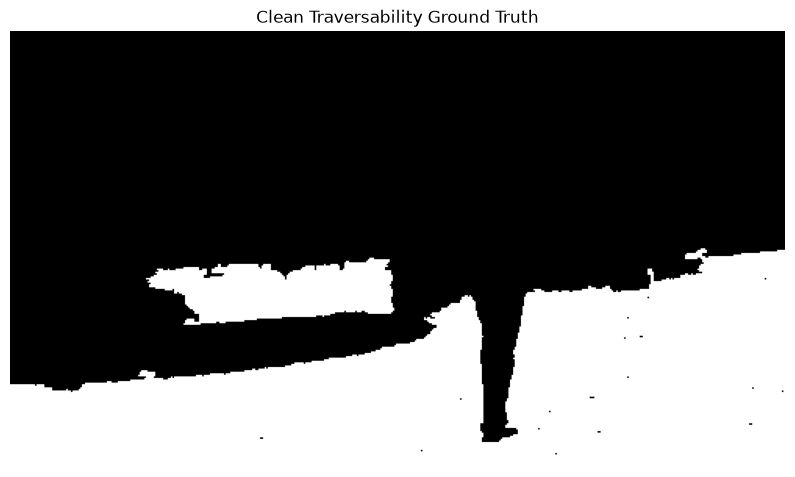

In [56]:
plt.figure(figsize=(10, 6))

plt.imshow(traversable_mask_clean, cmap="gray")

plt.title("Clean Traversability Ground Truth")
plt.axis("off")

plt.show()

In [57]:
# Resize original image
image_resized = image.resize(label.size)
image_array = np.array(image_resized)

# Use the clean binary mask as labels
y = traversable_mask_clean.astype(np.uint8)

# RGB features
X_rgb = image_array.reshape(-1, 3)

print("Feature shape:", X_rgb.shape)
print("Label shape:", y.reshape(-1).shape)

Feature shape: (138384, 3)
Label shape: (138384,)


In [58]:
from numpy.lib.stride_tricks import sliding_window_view

# Convert image to float
img = image_array.astype(np.float32) / 255.0

# Create 3x3 neighbourhoods
patches = sliding_window_view(img, (3, 3), axis=(0, 1))

# Flatten each 3x3x3 patch
X = patches.reshape(-1, 27)

# Remove border pixels from labels
y = y[1:-1, 1:-1].reshape(-1)

print("Feature shape:", X.shape)
print("Label shape:", y.shape)

Feature shape: (136838, 27)
Label shape: (136838,)


In [59]:
def prepare_image_pair(image_path, label_path):
    
    # Load images
    img = Image.open(image_path).convert("RGB")
    lbl = Image.open(label_path).convert("RGB")
    
    # Resize original to label size
    img = img.resize(lbl.size)
    
    # Convert to arrays
    img_array = np.array(img).astype(np.float32) / 255.0
    
    # Get clean labels
    clean_lbl = get_clean_label(lbl)
    
    # Binary target
    mask = (
        (clean_lbl == 0) |
        (clean_lbl == 1)
    )
    
    # Create 3x3 neighbourhoods
    patches = sliding_window_view(
        img_array,
        (3, 3),
        axis=(0, 1)
    )
    
    # Flatten each patch
    X = patches.reshape(-1, 27)
    
    # Remove border pixels from labels
    y = mask[1:-1, 1:-1].reshape(-1).astype(np.uint8)
    
    return X, y

In [60]:
test_X, test_y = prepare_image_pair(
    os.path.join(data_path, "left0586.jpg"),
    os.path.join(data_path, "left0586_sup.png")
)

print("X shape:", test_X.shape)
print("y shape:", test_y.shape)

X shape: (136838, 27)
y shape: (136838,)


In [61]:
all_X = []
all_y = []
image_names = []

for label_file in label_files:
    
    label_name = os.path.basename(label_file)
    original_name = label_name.replace("_sup.png", ".jpg")
    
    original_file = os.path.join(data_path, original_name)
    
    X_img, y_img = prepare_image_pair(
        original_file,
        label_file
    )
    
    all_X.append(X_img)
    all_y.append(y_img)
    image_names.append(original_name)
    
    print(
        original_name,
        "->",
        X_img.shape,
        y_img.shape
    )

print("\nAll images processed.")

left0586.jpg -> (136838, 27) (136838,)
left22088.jpg -> (136838, 27) (136838,)
left22331.jpg -> (136838, 27) (136838,)
left22741.jpg -> (136838, 27) (136838,)
left23075.jpg -> (136838, 27) (136838,)
left23761.jpg -> (136838, 27) (136838,)
left23945.jpg -> (136838, 27) (136838,)
left24496.jpg -> (136838, 27) (136838,)
left24875.jpg -> (136838, 27) (136838,)
left25057.jpg -> (136838, 27) (136838,)
left25343.jpg -> (136838, 27) (136838,)

All images processed.


In [62]:
X_all = np.vstack(all_X)
y_all = np.concatenate(all_y)

print("Final feature dataset:", X_all.shape)
print("Final label dataset:", y_all.shape)

print("Traversable samples:", np.sum(y_all == 1))
print("Non-traversable samples:", np.sum(y_all == 0))

Final feature dataset: (1505218, 27)
Final label dataset: (1505218,)
Traversable samples: 288752
Non-traversable samples: 1216466


In [63]:
image_ids = []

for i, X_img in enumerate(all_X):
    image_ids.extend([i] * len(X_img))

image_ids = np.array(image_ids)

print("Image ID shape:", image_ids.shape)
print("Unique image IDs:", np.unique(image_ids))

Image ID shape: (1505218,)
Unique image IDs: [ 0  1  2  3  4  5  6  7  8  9 10]


In [64]:
train_image_ids = np.arange(0, 9)
test_image_ids = np.arange(9, 11)

print("Training images:")

for i in train_image_ids:
    print(image_names[i])

print("\nTesting images:")

for i in test_image_ids:
    print(image_names[i])

Training images:
left0586.jpg
left22088.jpg
left22331.jpg
left22741.jpg
left23075.jpg
left23761.jpg
left23945.jpg
left24496.jpg
left24875.jpg

Testing images:
left25057.jpg
left25343.jpg


In [65]:
train_mask = np.isin(image_ids, train_image_ids)
test_mask = np.isin(image_ids, test_image_ids)

X_train = X_all[train_mask]
y_train = y_all[train_mask]

X_test = X_all[test_mask]
y_test = y_all[test_mask]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (1231542, 27)
y_train: (1231542,)
X_test: (273676, 27)
y_test: (273676,)


In [66]:
from sklearn.utils import resample

train_indices = np.arange(len(y_train))

traversable_indices = train_indices[y_train == 1]
non_traversable_indices = train_indices[y_train == 0]

print("Original traversable:", len(traversable_indices))
print("Original non-traversable:", len(non_traversable_indices))

# Number of samples per class
samples_per_class = 100000

rng = np.random.default_rng(42)

selected_traversable = rng.choice(
    traversable_indices,
    size=samples_per_class,
    replace=False
)

selected_non_traversable = rng.choice(
    non_traversable_indices,
    size=samples_per_class,
    replace=False
)

selected_indices = np.concatenate([
    selected_traversable,
    selected_non_traversable
])

rng.shuffle(selected_indices)

X_train_balanced = X_train[selected_indices]
y_train_balanced = y_train[selected_indices]

print("\nBalanced training dataset:")
print("X:", X_train_balanced.shape)
print("y:", y_train_balanced.shape)

print("Traversable:", np.sum(y_train_balanced == 1))
print("Non-traversable:", np.sum(y_train_balanced == 0))

Original traversable: 221777
Original non-traversable: 1009765



Balanced training dataset:
X: (200000, 27)
y: (200000,)
Traversable: 100000
Non-traversable: 100000


In [67]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

print("Training model...")

model.fit(
    X_train_balanced,
    y_train_balanced
)

print("Training completed!")

Training model...


Training completed!


In [68]:
y_pred = model.predict(X_test)

print("Prediction completed!")

print("Predictions:", y_pred.shape)
print("Actual labels:", y_test.shape)

Prediction completed!
Predictions: (273676,)
Actual labels: (273676,)


In [69]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy : 0.5735650915681316
Precision: 0.3574548831663189
Recall   : 0.9309891750653229
F1 Score : 0.5165713244218366

Confusion Matrix:
[[ 94618 112083]
 [  4622  62353]]


In [70]:
test_image_name = "left25057.jpg"

test_image_path = os.path.join(
    data_path,
    test_image_name
)

test_label_path = os.path.join(
    data_path,
    test_image_name.replace(".jpg", "_sup.png")
)

test_img = Image.open(test_image_path).convert("RGB")
test_lbl = Image.open(test_label_path).convert("RGB")

test_img = test_img.resize(test_lbl.size)

test_array = np.array(test_img).astype(np.float32) / 255.0

print("Test image size:", test_img.size)

Test image size: (496, 279)


In [71]:
test_patches = sliding_window_view(
    test_array,
    (3, 3),
    axis=(0, 1)
)

test_X = test_patches.reshape(-1, 27)

print("Test features:", test_X.shape)

Test features: (136838, 27)


In [72]:
test_prediction = model.predict(test_X)

print("Prediction shape:", test_prediction.shape)

Prediction shape: (136838,)


In [73]:
height = test_img.size[1]
width = test_img.size[0]

prediction_mask = test_prediction.reshape(
    height - 2,
    width - 2
)

print("Prediction mask:", prediction_mask.shape)

Prediction mask: (277, 494)


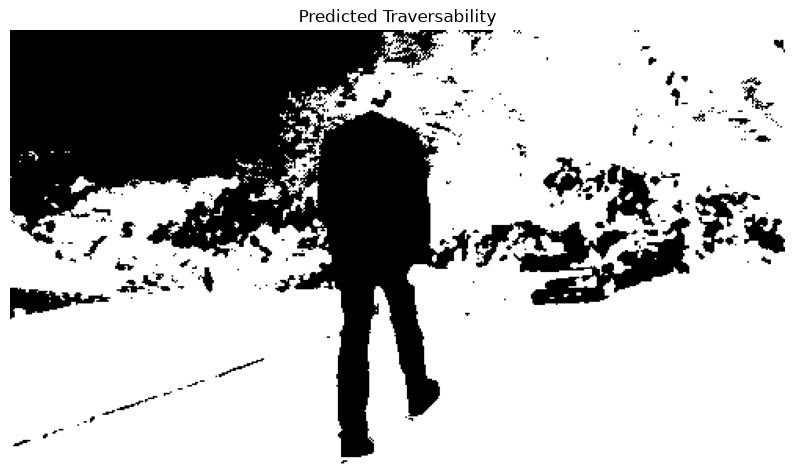

In [74]:
plt.figure(figsize=(10, 6))

plt.imshow(prediction_mask, cmap="gray")

plt.title("Predicted Traversability")

plt.axis("off")

plt.show()

In [75]:
test_clean_label = get_clean_label(test_lbl)

test_ground_truth = (
    (test_clean_label == 0) |
    (test_clean_label == 1)
)

# Remove border so dimensions match prediction
test_ground_truth = test_ground_truth[1:-1, 1:-1]

print("Ground truth:", test_ground_truth.shape)
print("Prediction:", prediction_mask.shape)

Ground truth: (277, 494)
Prediction: (277, 494)


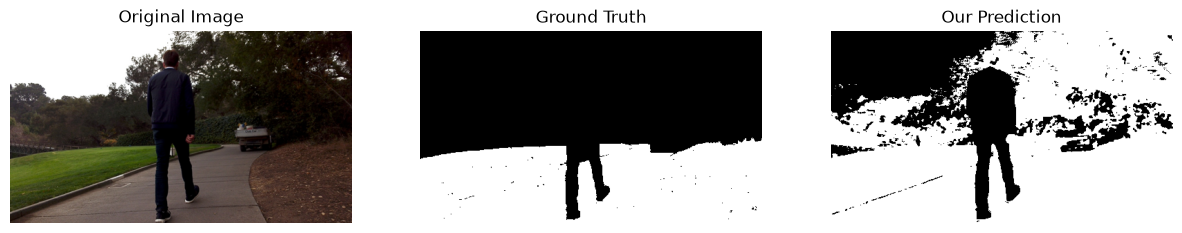

In [76]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(test_img)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(test_ground_truth, cmap="gray")
plt.title("Ground Truth")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(prediction_mask, cmap="gray")
plt.title("Our Prediction")
plt.axis("off")

plt.show()

In [77]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    n_jobs=-1,
    random_state=42
)

print("Training Random Forest...")

rf_model.fit(
    X_train_balanced,
    y_train_balanced
)

print("Random Forest training completed!")

Training Random Forest...
Random Forest training completed!


In [78]:
rf_pred = rf_model.predict(X_test)

print("Prediction completed!")
print("Prediction shape:", rf_pred.shape)

Prediction completed!
Prediction shape: (273676,)


In [79]:
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)

print("Random Forest Results")
print("---------------------")
print("Accuracy :", rf_accuracy)
print("Precision:", rf_precision)
print("Recall   :", rf_recall)
print("F1 Score :", rf_f1)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_pred))

Random Forest Results
---------------------
Accuracy : 0.7730930004823222
Precision: 0.5215885947046843
Recall   : 0.8794774169466218
F1 Score : 0.6548233790055863

Confusion Matrix:
[[152674  54027]
 [  8072  58903]]


In [80]:
# Predict only the first test image: left25057.jpg

rf_single_prediction = rf_model.predict(test_X)

rf_prediction_mask = rf_single_prediction.reshape(
    height - 2,
    width - 2
)

print("Random Forest prediction mask:",
      rf_prediction_mask.shape)

Random Forest prediction mask: (277, 494)


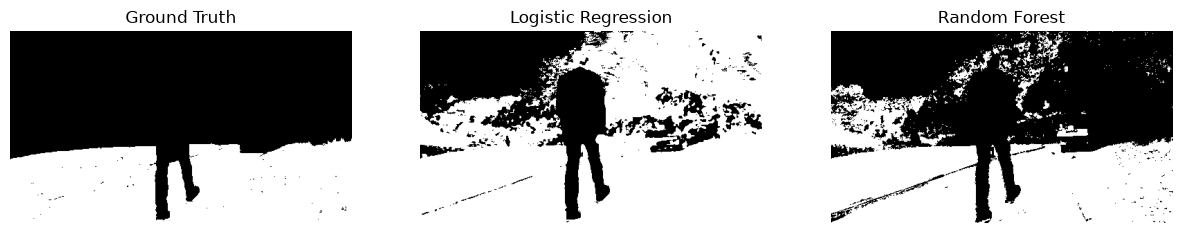

In [81]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(test_ground_truth, cmap="gray")
plt.title("Ground Truth")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(prediction_mask, cmap="gray")
plt.title("Logistic Regression")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(rf_prediction_mask, cmap="gray")
plt.title("Random Forest")
plt.axis("off")

plt.show()

In [82]:
# Divide the prediction mask into 3 regions
mask_height, mask_width = rf_prediction_mask.shape

left_region = rf_prediction_mask[:, :mask_width // 3]
center_region = rf_prediction_mask[:, mask_width // 3:2 * mask_width // 3]
right_region = rf_prediction_mask[:, 2 * mask_width // 3:]

# Calculate traversable percentage in each region
left_score = np.mean(left_region) * 100
center_score = np.mean(center_region) * 100
right_score = np.mean(right_region) * 100

print("LEFT traversable:", round(left_score, 2), "%")
print("CENTER traversable:", round(center_score, 2), "%")
print("RIGHT traversable:", round(right_score, 2), "%")

LEFT traversable: 51.86 %
CENTER traversable: 38.84 %
RIGHT traversable: 41.14 %


In [83]:
# Navigation decision based on traversability scores

threshold = 45

if center_score >= threshold:
    decision = "FORWARD"
elif left_score >= threshold and left_score > right_score:
    decision = "LEFT"
elif right_score >= threshold and right_score > left_score:
    decision = "RIGHT"
else:
    decision = "STOP"

print("Navigation Decision:", decision)

Navigation Decision: LEFT


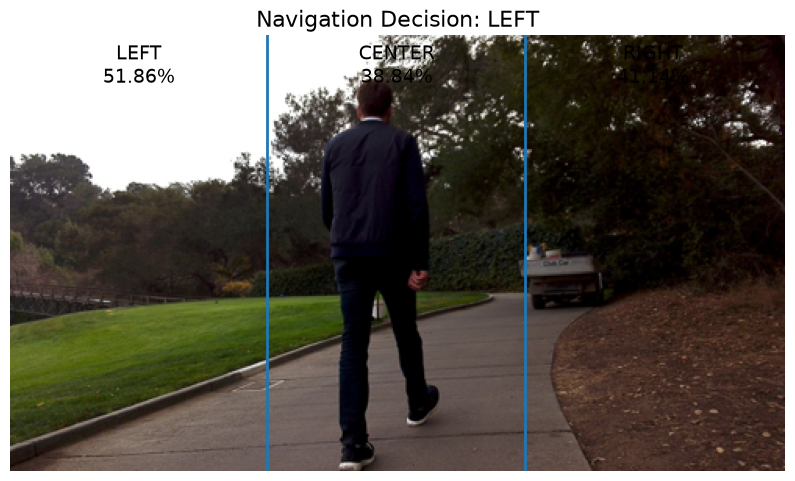

In [84]:
plt.figure(figsize=(10, 6))

plt.imshow(test_img)

plt.axvline(mask_width // 3, linewidth=2)
plt.axvline(2 * mask_width // 3, linewidth=2)

plt.text(
    mask_width // 6,
    30,
    f"LEFT\n{left_score:.2f}%",
    ha="center",
    fontsize=14
)

plt.text(
    mask_width // 2,
    30,
    f"CENTER\n{center_score:.2f}%",
    ha="center",
    fontsize=14
)

plt.text(
    5 * mask_width // 6,
    30,
    f"RIGHT\n{right_score:.2f}%",
    ha="center",
    fontsize=14
)

plt.title(f"Navigation Decision: {decision}", fontsize=16)
plt.axis("off")
plt.show()

In [85]:
import joblib
import os

model_path = "../src/model/random_forest_model.pkl"

joblib.dump(rf_model, model_path)

print("Model saved successfully!")
print("Saved at:", model_path)

Model saved successfully!
Saved at: ../src/model/random_forest_model.pkl


In [86]:
import joblib

loaded_model = joblib.load("../src/model/random_forest_model.pkl")

print("Saved model loaded successfully!")

Saved model loaded successfully!


In [87]:
loaded_prediction = loaded_model.predict(test_X)

print("Prediction completed!")
print("Prediction shape:", loaded_prediction.shape)

Prediction completed!
Prediction shape: (136838,)


In [88]:
# Improved navigation analysis
# Give more importance to the lower part of the image

height, width = rf_prediction_mask.shape

# Use the bottom 45% of the prediction mask
start_row = int(height * 0.55)
navigation_area = rf_prediction_mask[start_row:, :]

# Divide the navigation area into 3 zones
left_region = navigation_area[:, :width // 3]
center_region = navigation_area[:, width // 3:2 * width // 3]
right_region = navigation_area[:, 2 * width // 3:]

# Calculate traversability
left_score = np.mean(left_region) * 100
center_score = np.mean(center_region) * 100
right_score = np.mean(right_region) * 100

print("Improved Navigation Scores")
print("--------------------------")
print(f"LEFT:   {left_score:.2f}%")
print(f"CENTER: {center_score:.2f}%")
print(f"RIGHT:  {right_score:.2f}%")

Improved Navigation Scores
--------------------------
LEFT:   88.72%
CENTER: 71.26%
RIGHT:  87.56%


In [89]:
# Improved navigation decision

center_threshold = 60

if center_score >= center_threshold:
    improved_decision = "FORWARD"

elif left_score > right_score and left_score >= 60:
    improved_decision = "LEFT"

elif right_score > left_score and right_score >= 60:
    improved_decision = "RIGHT"

else:
    improved_decision = "STOP"

print("Improved Navigation Decision:", improved_decision)

Improved Navigation Decision: FORWARD
